# EDA

## Import libraries

In [1]:
# Import libraries required 
# for data analysis
import pandas as pd
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../data/ai4i2020.csv')

# Initial Checks

In [3]:
# Display the first few rows of the dataset
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Check for missing values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
# Check data types of each column
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

# Distribution Checks

### Class Imbalance

In [6]:
# Check for skewness in the target variable
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

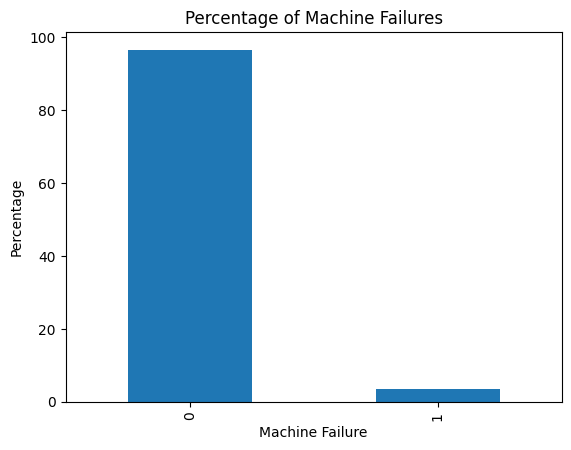

In [7]:
# Check visually for skewness in the target variable
# by plotting the failure counts as percentages
failure_counts = df['Machine failure'].value_counts(normalize=True) * 100
failure_counts.plot(kind='bar')
plt.xlabel('Machine Failure')
plt.ylabel('Percentage')
plt.title('Percentage of Machine Failures')
plt.show()

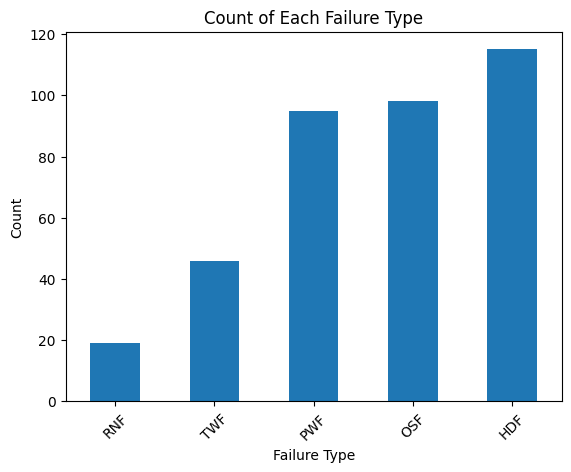

In [8]:
# Check individual failure types
failure_cols = [
    'TWF',  # Tool wear failure
    'HDF',  # Heat dissipation failure
    'PWF',  # Power failure
    'OSF',  # Overstrain failure
    'RNF'   # Random failures
]

df[failure_cols].sum().sort_values().plot(kind='bar')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.title('Count of Each Failure Type')
plt.xticks(rotation=45)
plt.show()

### Feature Distribution

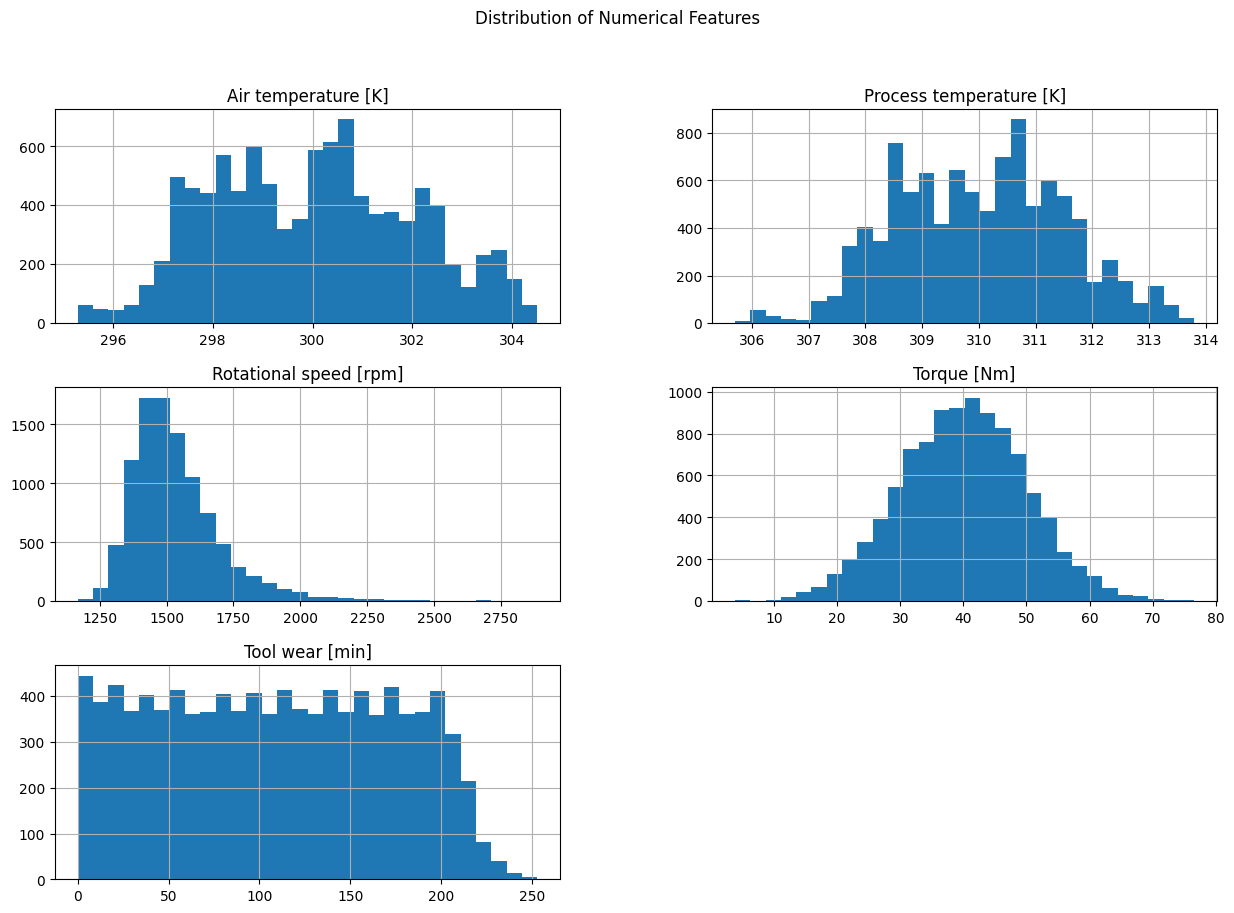

In [9]:
# Understand shape of each numerical feature
num_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[num_cols].hist(figsize=(15,10), bins=30)
plt.suptitle('Distribution of Numerical Features')
plt.show()

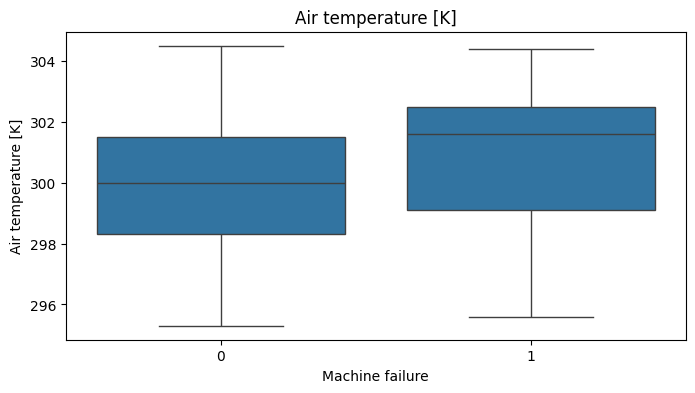

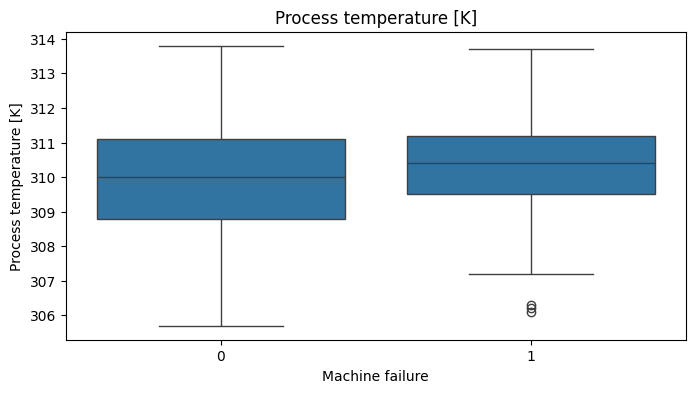

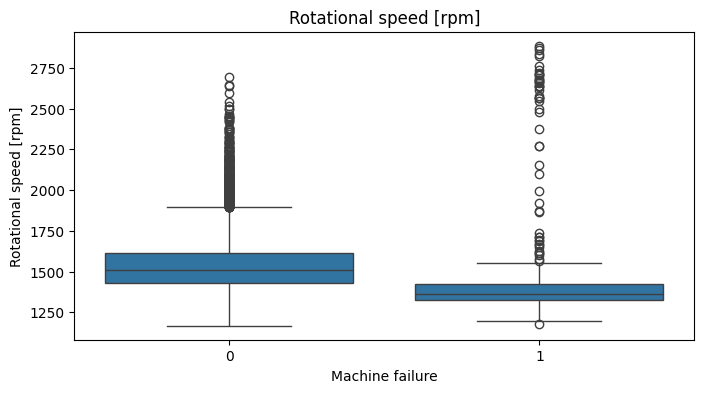

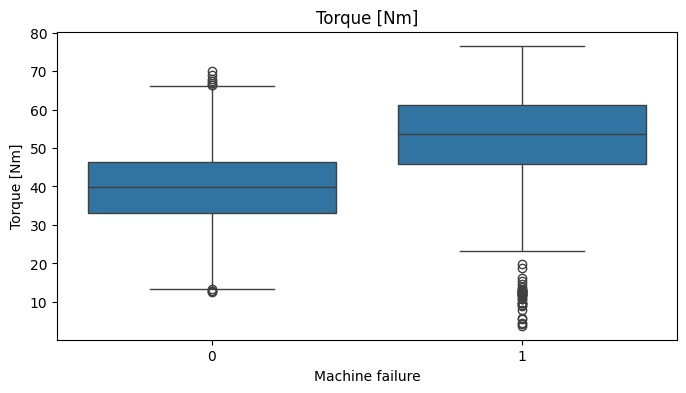

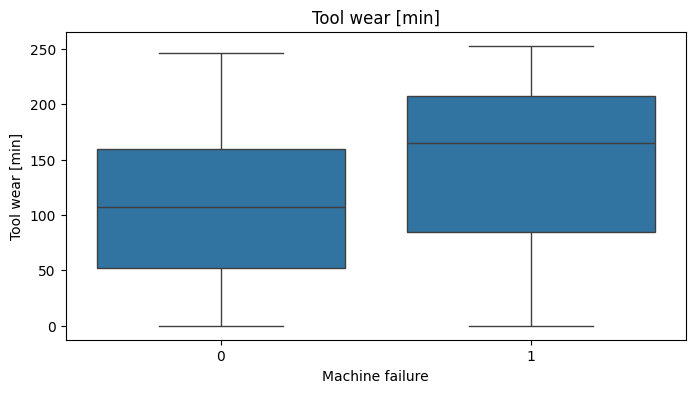

In [10]:
# Plot boxplots by failure status for numerical features
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Machine failure', y=col, data=df)
    plt.title(col)
    plt.show()

## Correlation Analysis

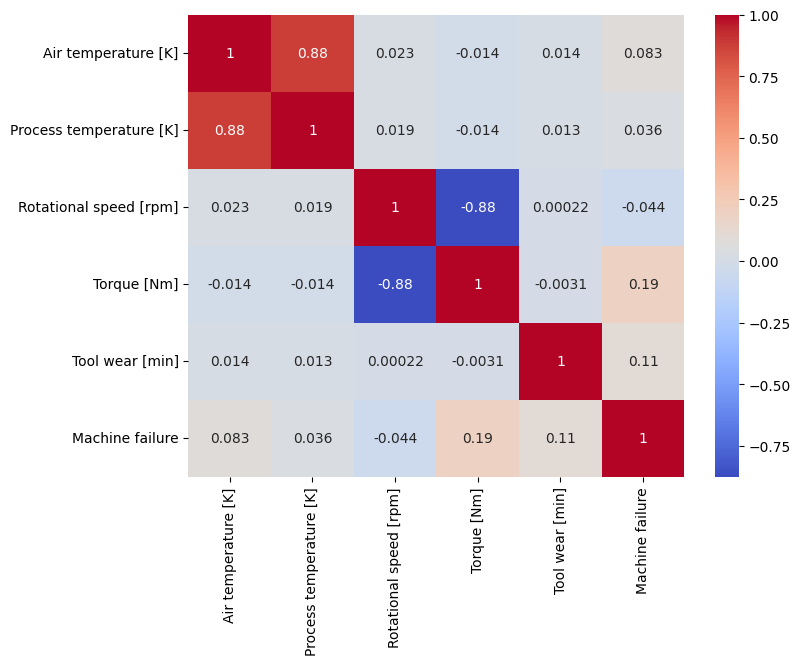

In [11]:
# Check relationships between operational variables
corr = df[num_cols + ['Machine failure']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Feature Relationship

/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/ivokafemann/Documents/Dokumente/Bildung/Onlinekurse/AI Engineering/Capstone 2/predictive-maintenance-capstone/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide

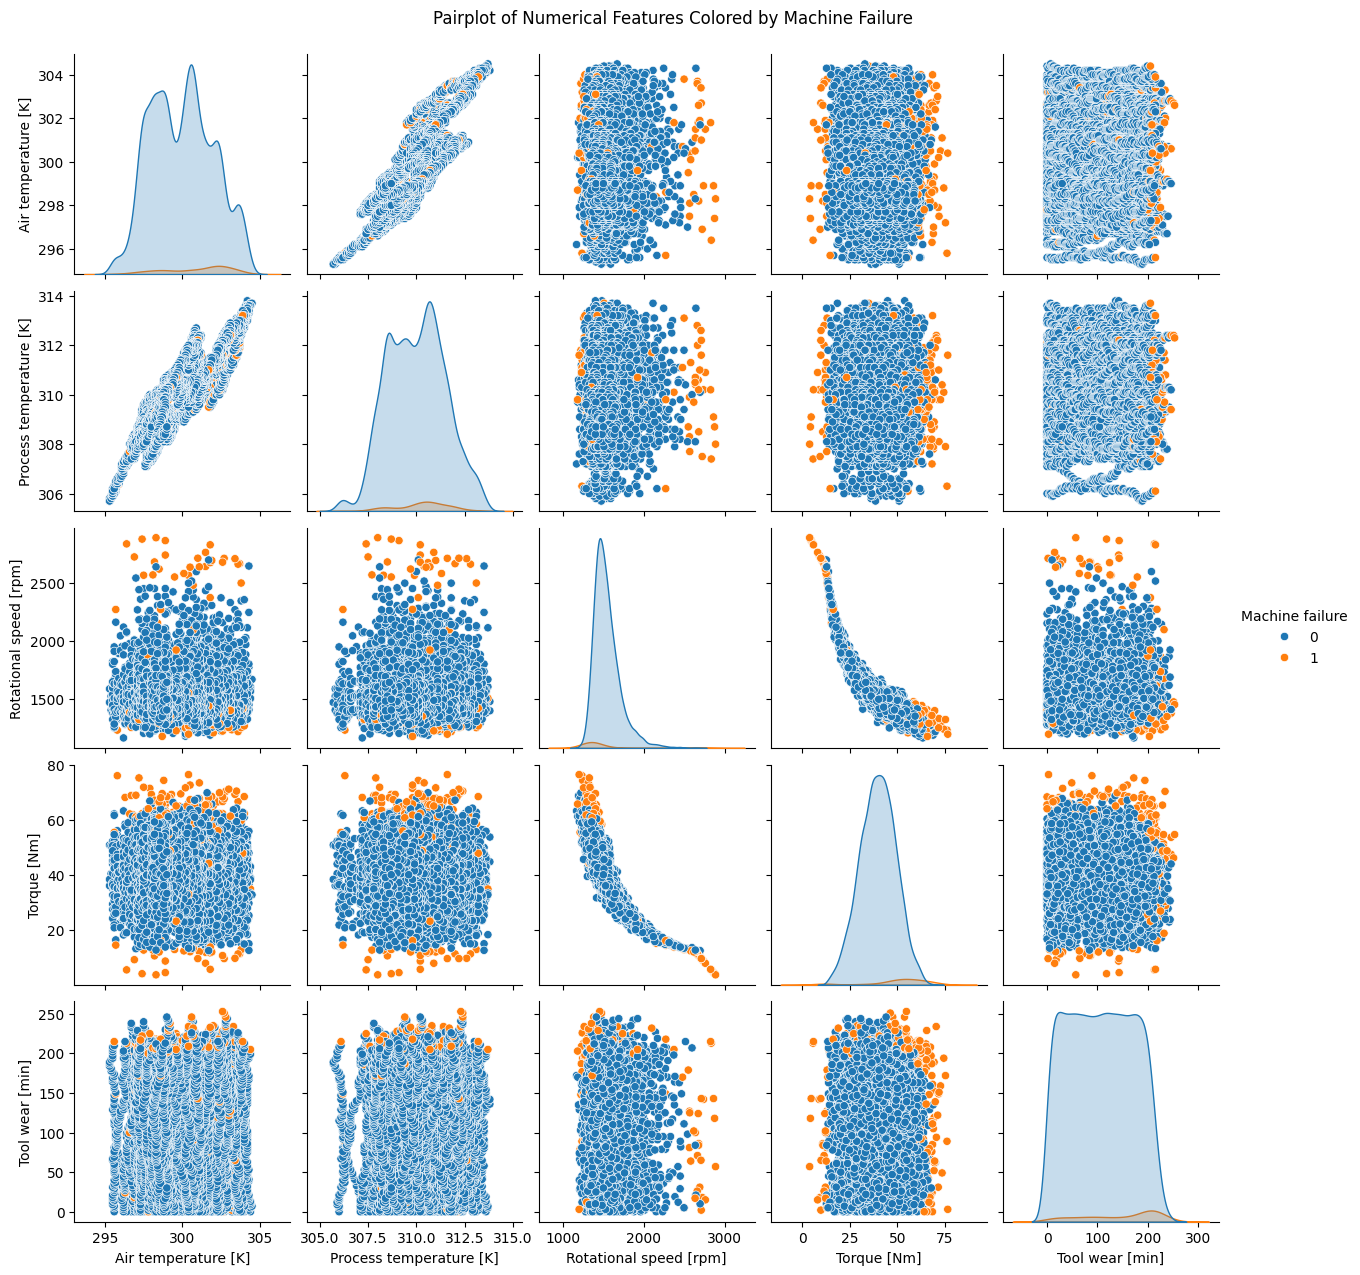

In [12]:
# Use pairplot to visualize relationships between features colored by failure status
sns.pairplot(df[num_cols + ['Machine failure']], hue='Machine failure', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features Colored by Machine Failure', y=1.02)
plt.show()

## Check Machine Type Effects

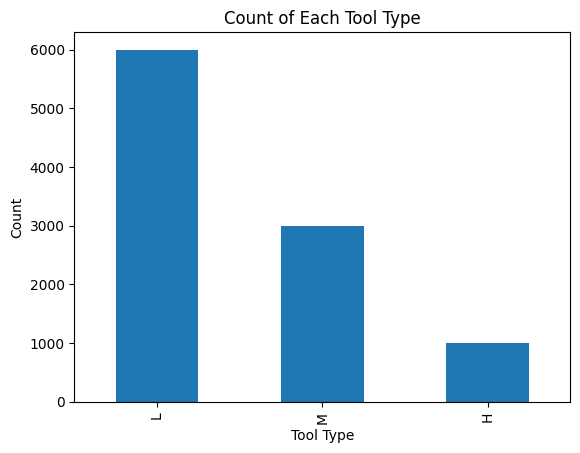

In [21]:
# Count the amount of different tool types
df['Type'].value_counts().plot(kind='bar')
plt.xlabel('Tool Type')
plt.ylabel('Count')
plt.title('Count of Each Tool Type')
plt.show()

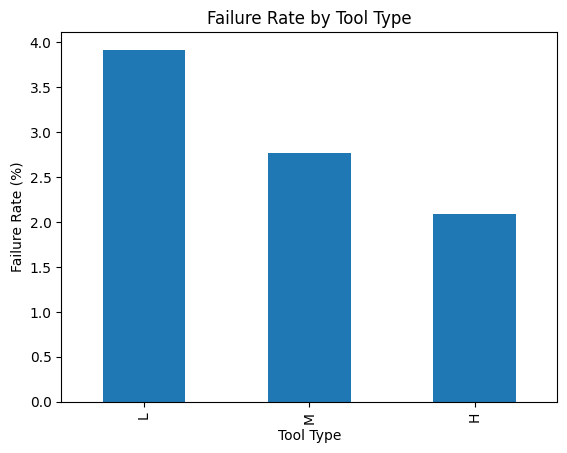

In [23]:
# Check the failure rate by tool type and sort in the order of failure rate
failure_rate_by_type = df.groupby('Type')['Machine failure'].mean() * 100
failure_rate_by_type = failure_rate_by_type.sort_values(ascending=False)

failure_rate_by_type.plot(kind='bar')
plt.xlabel('Tool Type')
plt.ylabel('Failure Rate (%)')
plt.title('Failure Rate by Tool Type')
plt.show()

### Derived Features Exploration

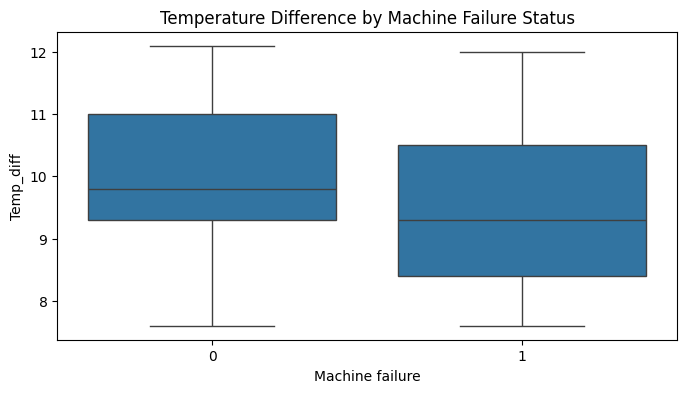

In [18]:
# Calculate temperature differences 
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# Check distribution of temperature differences by failure status
plt.figure(figsize=(8,4))
sns.boxplot(x='Machine failure', y='Temp_diff', data=df)
plt.title('Temperature Difference by Machine Failure Status')
plt.show()

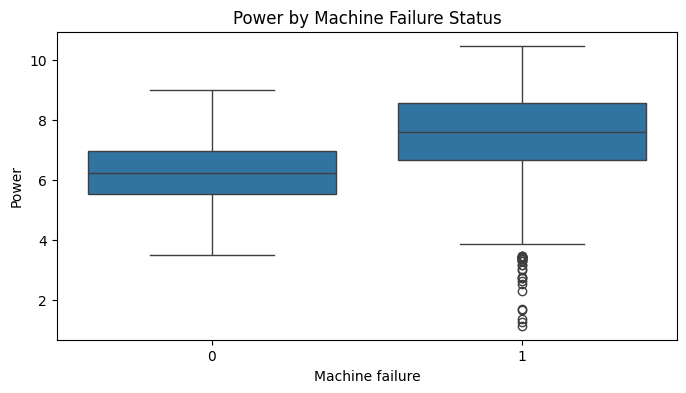

In [19]:
# Calculate power as product of torque and rotational speed
df['Power'] = (df['Torque [Nm]'] * df['Rotational speed [rpm]']) / 9550  # Convert to kW

# Check distribution of power by failure status
plt.figure(figsize=(8,4))
sns.boxplot(x='Machine failure', y='Power', data=df)
plt.title('Power by Machine Failure Status')
plt.show()